# 6 · The extended Kalman filter: map-based localisation

**Recap** ([theory](https://github.com/Rudip1/learn-state-estimation/blob/main/1_theory/06_ekf_localization.md)).
The EKF runs the Kalman equations on a linearisation: the mean goes through the nonlinear models,
$\bar x = f(\hat x, u)$ and $\nu = z - h(\bar x)$, the covariance through Jacobians, $\bar P = FPF^T + WQW^T$,
$S = H\bar PH^T + R$. For localisation with odometry, $f(x) = x\oplus u$ with $F = J_{1\oplus}$, $W = J_{2\oplus}$;
range–bearing readings of known landmarks are stacked into one update. When the belief is wide compared with the
curvature of the models the linearisation fails and the filter becomes over-confident; the iterated EKF
re-linearises the correction at its own iterates (Gauss–Newton) and repairs much of it.

In [1]:
# Installs the module when it is not available yet (e.g. on Colab). Building the C++ takes a few minutes.
try:
    import state_estimation
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-state-estimation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import state_estimation as se
from state_estimation import plotting

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6, 4.5)})

## Localising on a figure eight

Six landmarks, a sensor with 4 m range and 180° field of view scanning every 5 steps, and encoder odometry.

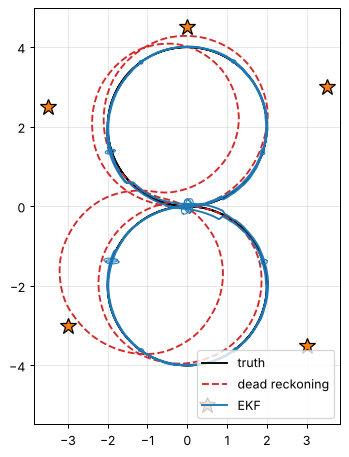

EKF: RMS position error 0.036 m; dead reckoning final error 0.38 m


In [3]:
landmarks = np.array([[0.0, 4.5], [3.5, 3.0], [3.0, -3.5], [-3.0, -3.0], [-3.5, 2.5], [0.5, -5.0]])
dd, dt, k = se.DifferentialDrive(0.1, 0.5), 0.1, 2e-4
sensor = se.RangeBearingSensor(max_range=4.0, fov=np.deg2rad(180), sigma_range=0.05, sigma_bearing=0.02)
u = np.vstack([se.figure_eight_controls(2.0, 200, dt)] * 2)
x0, P0 = np.zeros(3), np.diag([1e-4, 1e-4, 1e-5])

def run_ekf(run, scan_every=1, compass_every=0, compass_var=0.01**2, iterations=1, x_init=x0, P_init=P0):
    ekf = se.EkfLocalization(x_init, P_init)
    est, covs = [x_init], [P_init]
    for s, (dl, dr) in enumerate(run.wheel_travel):
        ekf.predict_wheels(dd, dl, dr, k * abs(dl), k * abs(dr))
        if run.scans[s] and (s + 1) % scan_every == 0:
            ekf.update_landmarks(run.scans[s], landmarks, sensor.R(), iterations)
        if compass_every and (s + 1) % compass_every == 0:
            ekf.update_compass(run.truth[s + 1, 2] + np.sqrt(compass_var) * np.random.default_rng(s).normal(), compass_var)
        est.append(ekf.pose); covs.append(ekf.covariance)
    return np.array(est), np.array(covs)

run = se.simulate_landmark_run(x0, u, dt, dd, k, sensor, landmarks, 1, se.Rng(3))
est, covs = run_ekf(run, scan_every=5)
dr = se.run_dead_reckoning(x0, P0, run.wheel_travel, dd, k)

ax = plotting.new_axes(figsize=(6, 6))
ax.plot(landmarks[:, 0], landmarks[:, 1], "*", color="C1", ms=13, mec="k")
plotting.plot_trajectory(ax, run.truth, "truth", "k")
plotting.plot_trajectory(ax, dr.poses, "dead reckoning", "C3", ls="--")
plotting.plot_trajectory(ax, est, "EKF", "C0")
for i in range(0, len(est), 40):
    plotting.plot_ellipse(ax, est[i], covs[i], 0.99, color="C0", lw=0.8)
ax.legend(); plt.show()
err = np.linalg.norm(run.truth[:, :2] - est[:, :2], axis=1)
print(f"EKF: RMS position error {np.sqrt(np.mean(err**2)):.3f} m; dead reckoning final error "
      f"{np.linalg.norm(run.truth[-1, :2] - dr.poses[-1, :2]):.2f} m")

### ✏️ Exercise 1 — the prediction step

Implement the EKF prediction for $f(x) = x\oplus u$ with displacement noise $Q_u$ (eq. 6.3, 6.4, 6.10) using
`se.compose`, `se.compose_jacobian_1` and `se.compose_jacobian_2`.

In [4]:
def ekf_predict(x, P, u, Qu):
    ### BEGIN SOLUTION
    F = se.compose_jacobian_1(x, u)
    W = se.compose_jacobian_2(x, u)
    return se.compose(x, u), F @ P @ F.T + W @ Qu @ W.T
    ### END SOLUTION

In [5]:
x, P = np.array([1.0, 2.0, 0.7]), np.diag([0.02, 0.03, 0.01])
u_, Qu = np.array([0.4, 0.05, 0.1]), np.diag([1e-3, 5e-4, 2e-4])
loc = se.EkfLocalization(x, P); loc.predict_displacement(u_, Qu)
xp, Pp = ekf_predict(x, P, u_, Qu)
assert np.allclose(xp, loc.pose) and np.allclose(Pp, loc.covariance)
print("✔ prediction matches")

✔ prediction matches


### ✏️ Exercise 2 — the stacked landmark update

Implement the update with a scan of range–bearing readings (eq. 6.5–6.9, 6.11–6.12). Wrap the bearing components
of the innovation and the heading of the result.

In [6]:
def ekf_update(x, P, scan, landmarks, R):
    ### BEGIN SOLUTION
    z = np.concatenate([o.z for o in scan])
    zhat = np.concatenate([se.range_bearing(x, landmarks[o.landmark]) for o in scan])
    H = np.vstack([se.range_bearing_jacobian_pose(x, landmarks[o.landmark]) for o in scan])
    Rs = np.kron(np.eye(len(scan)), R)
    nu = z - zhat
    nu[1::2] = [se.wrap_angle(a) for a in nu[1::2]]
    S = H @ P @ H.T + Rs
    K = np.linalg.solve(S, H @ P).T
    I_KH = np.eye(3) - K @ H
    xn = x + K @ nu
    xn[2] = se.wrap_angle(xn[2])
    return xn, I_KH @ P @ I_KH.T + K @ Rs @ K.T
    ### END SOLUTION

In [7]:
wide = se.RangeBearingSensor(10.0, 2 * np.pi, 0.05, 0.02)
scan = wide.observe(np.array([0.5, 0.3, 0.2]), landmarks, se.Rng(5))
x, P = np.array([0.4, 0.4, 0.25]), np.diag([0.05, 0.05, 0.02])
loc = se.EkfLocalization(x, P); loc.update_landmarks(scan, landmarks, sensor.R())
xn, Pn = ekf_update(x, P, scan, landmarks, sensor.R())
assert np.allclose(xn, loc.pose) and np.allclose(Pn, loc.covariance)
print(f"✔ update matches ({len(scan)} landmarks in the scan)")

✔ update matches (6 landmarks in the scan)


### ✏️ Exercise 3 — how often must we see landmarks?

Run the filter on the same data with scans used every 1, 5, 20 and 50 steps, with and without a compass reading
every step ($\sigma = 0.01$ rad), and return the RMS position error of each configuration as a dict
`{(scan_every, compass): rms}`.

In [8]:
def rate_study():
    ### BEGIN SOLUTION
    out = {}
    for every in (1, 5, 20, 50):
        for compass in (False, True):
            e, _ = run_ekf(run, scan_every=every, compass_every=1 if compass else 0)
            out[(every, compass)] = float(np.sqrt(np.mean(np.sum((run.truth[:, :2] - e[:, :2])**2, axis=1))))
    return out
    ### END SOLUTION

In [9]:
rms = rate_study()
for (every, compass), v in rms.items():
    print(f"scan every {every:2d} steps, compass {'on ' if compass else 'off'}: RMS {v:.3f} m")
assert rms[(1, False)] < rms[(50, False)]
assert rms[(50, True)] < rms[(50, False)]

scan every  1 steps, compass off: RMS 0.025 m
scan every  1 steps, compass on : RMS 0.012 m
scan every  5 steps, compass off: RMS 0.036 m
scan every  5 steps, compass on : RMS 0.018 m
scan every 20 steps, compass off: RMS 0.066 m
scan every 20 steps, compass on : RMS 0.026 m
scan every 50 steps, compass off: RMS 0.247 m
scan every 50 steps, compass on : RMS 0.025 m


## 🔨 Break it — linearising a wide belief

The robot starts at the origin with heading standard deviation $\sigma_\theta$, drives 3 m straight, then sees two
landmarks. For each $\sigma_\theta$, 2000 trials compare the EKF with the iterated EKF (10 iterations) by the NEES
after the correction (consistent: mean 3, 95 % of the trials below $\chi^2_3(0.95) = 7.81$).

σθ = 0.05 rad, EKF : mean NEES     3.1,  94.5 % below the 95 % gate
σθ = 0.05 rad, IEKF: mean NEES     3.0,  95.0 % below the 95 % gate


σθ = 0.20 rad, EKF : mean NEES    15.0,  67.8 % below the 95 % gate
σθ = 0.20 rad, IEKF: mean NEES     3.2,  93.9 % below the 95 % gate


σθ = 0.40 rad, EKF : mean NEES    97.1,  39.4 % below the 95 % gate
σθ = 0.40 rad, IEKF: mean NEES     8.3,  79.2 % below the 95 % gate
σθ = 0.60 rad, EKF : mean NEES   325.8,  27.9 % below the 95 % gate
σθ = 0.60 rad, IEKF: mean NEES    42.6,  61.4 % below the 95 % gate


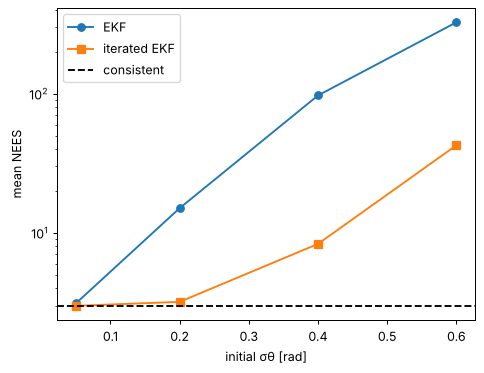

In [10]:
lm2 = np.array([[4.0, 2.0], [5.0, -1.5]])
far_sensor = se.RangeBearingSensor(100, 2 * np.pi, 0.05, 0.02)
u3, Q3 = np.array([3.0, 0.0, 0.0]), np.diag([1e-4, 1e-4, 1e-5])
gate = se.chi2_quantile(0.95, 3)
sigmas = (0.05, 0.2, 0.4, 0.6)
table = {1: [], 10: []}
for sth in sigmas:
    P0w = np.diag([0.01, 0.01, sth**2]); rng = se.Rng(1)
    vals = {1: [], 10: []}
    for _ in range(2000):
        x_start = se.sample_gaussian(np.zeros(3), P0w, 1, rng)[0]
        x_true = se.compose(x_start, se.sample_gaussian(u3, Q3, 1, rng)[0])
        obs = far_sensor.observe(x_true, lm2, rng)
        for it in (1, 10):
            f = se.EkfLocalization(np.zeros(3), P0w); f.predict_displacement(u3, Q3); f.update_landmarks(obs, lm2, sensor.R(), it)
            d = x_true - f.pose; d[2] = se.wrap_angle(d[2])
            vals[it].append(d @ np.linalg.solve(f.covariance, d))
    for it in (1, 10):
        table[it].append(np.mean(vals[it]))
        print(f"σθ = {sth:4.2f} rad, {'EKF ' if it == 1 else 'IEKF'}: mean NEES {np.mean(vals[it]):7.1f}, "
              f"{100 * np.mean(np.array(vals[it]) <= gate):5.1f} % below the 95 % gate")
plt.semilogy(sigmas, table[1], "o-", label="EKF"); plt.semilogy(sigmas, table[10], "s-", label="iterated EKF")
plt.axhline(3, color="k", ls="--", label="consistent"); plt.xlabel("initial σθ [rad]"); plt.ylabel("mean NEES")
plt.legend(); plt.show()

## 🔨 Break it — under-estimated odometry noise

Tell the filter that the encoders are ten times better than they are. Between scans it believes its own
prediction too much; the NEES averaged over 20 runs leaves the bounds.

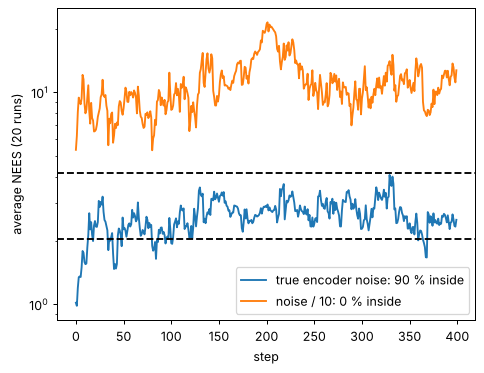

In [11]:
def nees_runs(k_filter, runs=20, steps=400):
    total = np.zeros(steps)
    for r in range(runs):
        rr = se.simulate_landmark_run(x0, u[:steps], dt, dd, k, sensor, landmarks, 5, se.Rng(100 + r))
        f = se.EkfLocalization(x0, P0)
        for s, (dl, dr_) in enumerate(rr.wheel_travel):
            f.predict_wheels(dd, dl, dr_, k_filter * abs(dl), k_filter * abs(dr_))
            f.update_landmarks(rr.scans[s], landmarks, sensor.R())
            d = rr.truth[s + 1] - f.pose; d[2] = se.wrap_angle(d[2])
            total[s] += d @ np.linalg.solve(f.covariance, d)
    return total / runs
lo, hi = se.average_chi2_bounds(3, 20)
for kf_, name in ((k, "true encoder noise"), (k / 10, "noise / 10")):
    n = nees_runs(kf_)
    plt.semilogy(n, label=f"{name}: {100 * np.mean((n >= lo) & (n <= hi)):.0f} % inside")
plt.axhline(lo, color="k", ls="--"); plt.axhline(hi, color="k", ls="--")
plt.xlabel("step"); plt.ylabel("average NEES (20 runs)"); plt.legend(); plt.show()

## What to remember

- The EKF propagates the mean through the true models and the covariance through Jacobians at the current estimate.
- Localisation = dead-reckoning prediction ($x\oplus u$) + stacked landmark corrections; the uncertainty is a
  saw-tooth whose height depends on how often landmarks are seen.
- Wide beliefs break the linearisation and make the filter over-confident; the iterated EKF fixes much of the
  correction step.
- Honest noise models matter as much as the equations: check NEES/NIS.